In [ ]:
# importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [ ]:
# lendo o dataframe
df = pd.read_csv('/datasets/games.csv')

In [1]:
# obtendo as 10 primeiras linhas do df
print(df.head(10))

                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii           2008.0        Racing   
3          Wii Sports Resort      Wii           2009.0        Sports   
4   Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                     Tetris       GB           1989.0        Puzzle   
6      New Super Mario Bros.       DS           2006.0      Platform   
7                   Wii Play      Wii           2006.0          Misc   
8  New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                  Duck Hunt      NES           1984.0       Shooter   

   NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      6.81         0.77     

In [2]:
# obtendo informações gerais sobre os nossos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
# Convertendo os nomes das colunas em minúsculas 
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [4]:
# Contando os valores ausentes
df.isnull().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [5]:
# Verificando se há duplicados completos
df.duplicated().sum()

0

In [ ]:
# Convertendo 'year_of_release' em número inteiro
df["year_of_release"] = df["year_of_release"].astype("Int64")

In [ ]:
# Convertendo 'user_score' para número flutuante e transformou TBD em NaN
df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce")

In [ ]:
# Substituindo os valores ausentes de 'rating' por unknown
df["rating"] = df["rating"].fillna("unknown")

- Valores numéricos (como user_score) foram mantidos como NaN para não distorcer análises.
- Na coluna rating, os ausentes foram substituídos por "unknown", por se tratar de uma categoria.
- Valores ausentes podem ocorrer por falta de avaliações ou dados não informados.
- "TBD" foi convertido para NaN, pois não representa uma nota real.

In [6]:
# Criando coluna e calculando o total de vendas para cada jogo
df["total_sales"] = df[
    ["na_sales", "eu_sales", "jp_sales", "other_sales"]
].sum(axis=1)
df[["name", "total_sales"]].head(10)

,name,total_sales
0,Wii Sports,82.54
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.38
5,Tetris,30.26
6,New Super Mario Bros.,29.80
7,Wii Play,28.91
8,New Super Mario Bros. Wii,28.32
9,Duck Hunt,28.31


In [7]:
# Visualizando os jogos mais vendidos
df.sort_values(by="total_sales", ascending=False).head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38


In [8]:
# Quantidade de jogos por ano
df["year_of_release"].value_counts().sort_index()

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

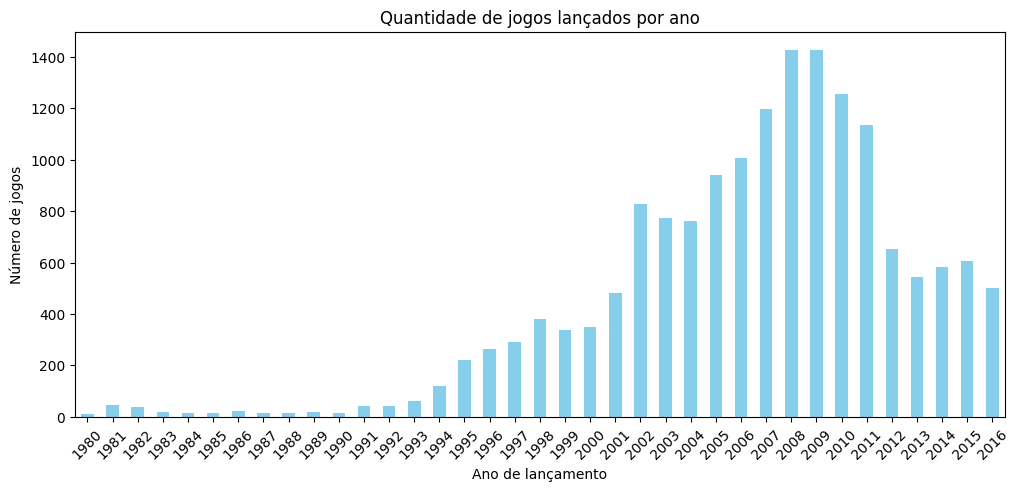

In [9]:
# Gráfico de barras
games_per_year = df["year_of_release"].value_counts().sort_index()

plt.figure(figsize=(12,5))
games_per_year.plot(kind="bar", color="skyblue")
plt.title("Quantidade de jogos lançados por ano")
plt.xlabel("Ano de lançamento")
plt.ylabel("Número de jogos")
plt.xticks(rotation=45)
plt.show()

In [10]:
# Quantidade de jogos por plataforma
df["platform"].value_counts()

PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      430
PS4      392
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
WS         6
SCD        6
3DO        3
TG16       2
GG         1
PCFX       1
Name: platform, dtype: int64

In [11]:
# Calcular primeiro e último ano por plataforma
platform_years = df.groupby("platform")["year_of_release"].agg(["min", "max"])

platform_years["life_cycle"] = (
    platform_years["max"] - platform_years["min"]
)

platform_years.head()

,min,max,life_cycle
platform,,,
2600,1980,1989,9
3DO,1994,1995,1
3DS,2011,2016,5
DC,1998,2008,10
DS,1985,2013,28


In [12]:
# Calcular estatística do ciclo de vida
platform_years["life_cycle"].describe()

count    31.000000
mean      7.612903
std       6.998464
min       0.000000
25%       3.000000
50%       6.000000
75%      10.000000
max      31.000000
Name: life_cycle, dtype: float64

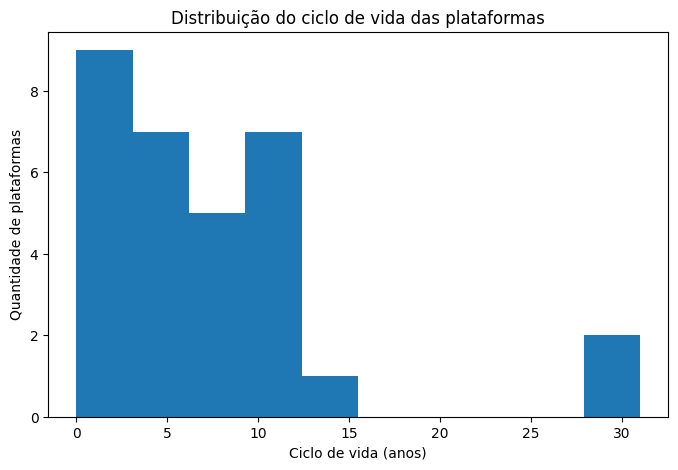

In [13]:
# Criando histograma para visualizar a distribuição 
plt.figure(figsize=(8,5))
platform_years["life_cycle"].plot(kind="hist", bins=10)
plt.title("Distribuição do ciclo de vida das plataformas")
plt.xlabel("Ciclo de vida (anos)")
plt.ylabel("Quantidade de plataformas")
plt.show()

In [14]:
# Calcular vendas totais por ano e plataforma
sales_per_year = df.groupby(["platform", "year_of_release"])["total_sales"].sum().reset_index()
sales_per_year.describe()

,year_of_release,total_sales
count,238.000000,238.000000
mean,2002.474790,37.045336
std,9.030036,48.486384
min,1980.000000,0.020000
25%,1996.000000,3.620000
50%,2003.000000,16.055000
75%,2010.000000,50.477500
max,2016.000000,211.810000


In [15]:
# Calcular duração do ciclo de vida
platform_years["life_cycle"] = platform_years["max"] - platform_years["min"]
platform_years.head()

,min,max,life_cycle
platform,,,
2600,1980,1989,9
3DO,1994,1995,1
3DS,2011,2016,5
DC,1998,2008,10
DS,1985,2013,28


In [16]:
#Calcular média do ciclo de vida
platform_years["life_cycle"].mean()

7.612903225806452

In [17]:
# Soma de vendas por ano de cada plataforma
sales = df.groupby(["platform", "year_of_release"])["total_sales"].sum().reset_index()
sales.head()

,platform,year_of_release,total_sales
0,2600,1980,11.38
1,2600,1981,35.68
2,2600,1982,28.88
3,2600,1983,5.84
4,2600,1984,0.27


In [18]:
# Calcular ano com maior venda de cada plataforma
peak = sales.loc[sales.groupby("platform")["total_sales"].idxmax()]
peak.head()

,platform,year_of_release,total_sales
1,2600,1981,35.68
11,3DO,1995,0.08
12,3DS,2011,63.20
20,DC,2000,5.99
29,DS,2007,146.94


In [19]:
# Comparar primeiro ano de venda com ano de pico de vendas de cada plataforma
peak = peak.merge(platform_years["min"], left_on="platform", right_index=True)

peak["years_to_peak"] = peak["year_of_release"] - peak["min"]
peak.head()

,platform,year_of_release,total_sales,min,years_to_peak
1,2600,1981,35.68,1980,1
11,3DO,1995,0.08,1994,1
12,3DS,2011,63.20,2011,0
20,DC,2000,5.99,1998,2
29,DS,2007,146.94,1985,22


In [20]:
# Calcular média de tempo até atingir o pico de vendas
peak["years_to_peak"].mean()

3.3870967741935485

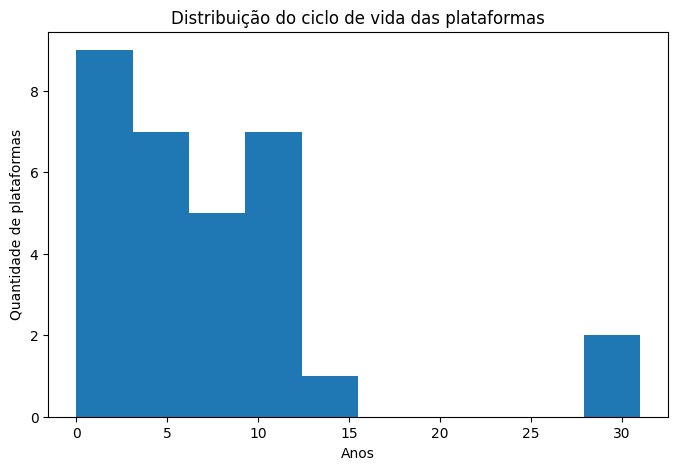

In [21]:
# Criando gráfico de distribuição 
plt.figure(figsize=(8,5))
platform_years["life_cycle"].plot(kind="hist", bins=10)
plt.title("Distribuição do ciclo de vida das plataformas")
plt.xlabel("Anos")
plt.ylabel("Quantidade de plataformas")
plt.show()

O ciclo de vida médio das plataformas é de aproximadamente 7 anos.
Em média, as plataformas levam cerca de 3 anos para atingir seu pico de vendas após o lançamento.

In [22]:
# Criando variável 'top_platforms'
top_platforms = df.groupby("platform")["total_sales"].sum().sort_values(ascending=False).head(5).index
print(top_platforms)

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')


In [23]:
# Venda total das plataformas de acordo com o ano
df[df["platform"].isin(top_platforms)] \
  .groupby(["year_of_release", "platform"])["total_sales"] \
  .sum().unstack()


platform,DS,PS2,PS3,Wii,X360
year_of_release,,,,,
1985,0.02,NaN,NaN,NaN,NaN
2000,NaN,39.17,NaN,NaN,NaN
2001,NaN,166.43,NaN,NaN,NaN
2002,NaN,205.38,NaN,NaN,NaN
2003,NaN,184.31,NaN,NaN,NaN
2004,17.27,211.81,NaN,NaN,NaN
2005,130.14,160.66,NaN,NaN,8.25
2006,119.81,103.42,20.96,137.15,51.62
2007,146.94,75.99,73.19,152.77,95.41


In [24]:

# Filtrar o dataframe entre 2012 e 2017
df = df[(df["year_of_release"] >= 2012) & 
               (df["year_of_release"] <= 2017)]

df["year_of_release"].min(), df["year_of_release"].max()


(2012, 2016)

As plataformas geralmente duram entre 7 e 10 anos. Elas crescem, atingem um ponto alto de vendas e depois começam a cair até praticamente deixarem de vender.

A partir de 2012, é possível ver uma mudança para uma nova geração de consoles. Por isso, esse período é mais adequado para analisar tendências e fazer previsões para 2017.

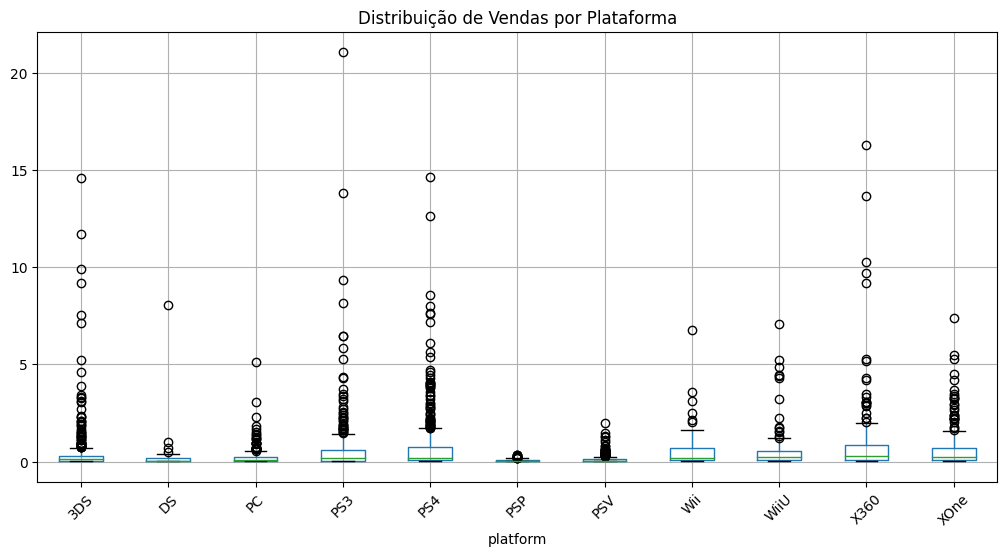

In [25]:
# Criando diagrama de caixa para visualizar as vendas globais por plataforma
df.boxplot(column="total_sales", by="platform", figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Distribuição de Vendas por Plataforma")
plt.suptitle("")
plt.show()

In [26]:
# Vendas médias em cada plataforma
df.groupby("platform")["total_sales"].mean().sort_values(ascending=False)

platform
X360    0.810068
PS4     0.801378
Wii     0.655000
XOne    0.645020
PS3     0.585781
WiiU    0.559116
3DS     0.491439
DS      0.404839
PC      0.250600
PSV     0.119659
PSP     0.064682
Name: total_sales, dtype: float64

O gráfico mostra que a maioria dos jogos vende pouco em todas as plataformas. Porém, existem alguns poucos jogos que vendem muito e aparecem como pontos fora da curva.

As diferenças entre as plataformas não são muito grandes na maior parte dos jogos. Em alguns casos, a média é maior porque poucos jogos fizeram muito sucesso e aumentaram o valor geral.

In [ ]:
# Filtrando apenas PS2
ps2 = df[df["platform"] == "PS2"]

In [27]:
# Calculando correlação entre avaliações e vendas totais
ps2["user_score"].corr(ps2["total_sales"])

nan

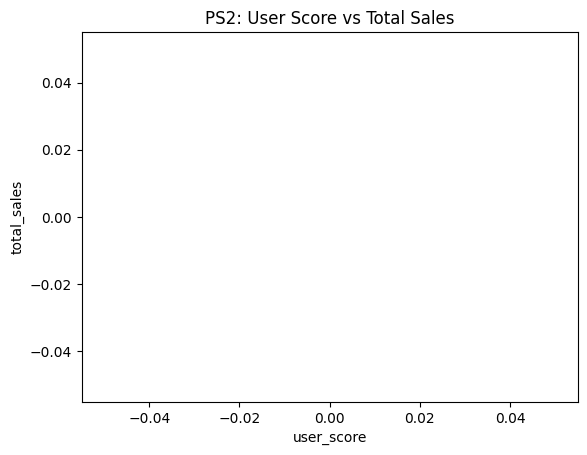

In [28]:
# Gráfico de dispersão de nota dos usuários 
ps2.plot.scatter(x="user_score", y="total_sales")
plt.title("PS2: User Score vs Total Sales")
plt.show()

A correlação entre as avaliações dos usuários e as vendas no PS2 é fraca (≈ 0,17). Isso indica que a nota tem pouca influência nas vendas, e que outros fatores, como marketing ou popularidade da franquia, provavelmente têm maior impacto.

In [29]:
# Comparando vendas de jogos em diferentes plataformas
games = ["Grand Theft Auto V", "FIFA 15", "Call of Duty: Black Ops"]

df[df["name"].isin(games)] \
  .groupby(["name", "platform"])["total_sales"] \
  .sum()

name                platform
FIFA 15             3DS          0.46
                    PC           0.29
                    PS3          4.28
                    PS4          6.08
                    PSV          0.60
                    Wii          0.56
                    X360         2.92
                    XOne         2.18
Grand Theft Auto V  PC           1.17
                    PS3         21.05
                    PS4         12.62
                    X360        16.27
                    XOne         5.47
Name: total_sales, dtype: float64

Ao comparar os mesmos jogos em diferentes plataformas, percebe-se que as vendas mudam. Alguns jogos vendem mais em certos consoles, mostrando que o sucesso depende não só do jogo, mas também da plataforma.

In [30]:
# Quantidade de jogos por gênero
df["genre"].value_counts()

Action          1031
Role-Playing     370
Adventure        302
Sports           268
Shooter          235
Misc             192
Racing           115
Fighting         109
Platform          85
Simulation        80
Strategy          71
Puzzle            28
Name: genre, dtype: int64

In [31]:
# Vendas totais por gênero
df.groupby("genre")["total_sales"].sum().sort_values(ascending=False)

genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64

Gêneros como Action, Sports e Shooter vendem mais, enquanto Puzzle, Adventure e Strategy vendem menos. Isso não significa que existam menos jogos desses gêneros, já que Adventure tem uma quantidade média de jogos comparado aos outros.

In [32]:
# Vendas por plataforma em cada região
na_top = df.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head(5)
eu_top = df.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head(5)
jp_top = df.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head(5)
other_top = df.groupby("platform")["other_sales"].sum().sort_values(ascending=False).head(5)

print("Top 5 plataformas - América do Norte")
print(na_top)
print("\nTop 5 plataformas - Europa")
print(eu_top)
print("\nTop 5 plataformas - Japão")
print(jp_top)
print("\nTop 5 plataformas - Outros Lugares")
print(other_top)

Top 5 plataformas - América do Norte
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 plataformas - Europa
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 plataformas - Japão
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64

Top 5 plataformas - Outros Lugares
platform
PS4     48.35
PS3     43.26
X360    20.40
XOne    14.27
3DS      8.87
Name: other_sales, dtype: float64


In [33]:
# Vendas por gênero em cada região
na_genre_top = df.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head(5)
eu_genre_top = df.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head(5)
jp_genre_top = df.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head(5)
other_genre_top = df.groupby("genre")["other_sales"].sum().sort_values(ascending=False).head(5)

print("Top 5 gêneros - América do Norte")
print(na_genre_top)
print("\nTop 5 gêneros - Europa")
print(eu_genre_top)
print("\nTop 5 gêneros - Japão")
print(jp_genre_top)
print("\nTop 5 gêneros - Outros Lugares")
print(other_genre_top)

Top 5 gêneros - América do Norte
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Top 5 gêneros - Europa
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Top 5 gêneros - Japão
genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64

Top 5 gêneros - Outros Lugares
genre
Action          51.14
Shooter         37.26
Sports          22.44
Role-Playing    14.83
Misc             7.67
Name: other_sales, dtype: float64


In [34]:
# Total de vendas por rating para cada região
na_rating = df.groupby("rating")["na_sales"].sum().sort_values(ascending=False)
eu_rating = df.groupby("rating")["eu_sales"].sum().sort_values(ascending=False)
jp_rating = df.groupby("rating")["jp_sales"].sum().sort_values(ascending=False)
other_rating = df.groupby("rating")["other_sales"].sum().sort_values(ascending=False)

print("Vendas por Rating - América do Norte")
print(na_rating)
print("\nVendas por Rating - Europa")
print(eu_rating)
print("\nVendas por Rating - Japão")
print(jp_rating)
print("\nVendas por Rating - Outros Lugares")
print(other_rating)

Vendas por Rating - América do Norte
rating
M          231.57
E          114.37
unknown    103.31
E10+        75.70
T           66.02
Name: na_sales, dtype: float64

Vendas por Rating - Europa
rating
M          193.96
E          113.03
unknown     91.50
E10+        55.37
T           52.96
Name: eu_sales, dtype: float64

Vendas por Rating - Japão
rating
unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: jp_sales, dtype: float64

Vendas por Rating - Outros Lugares
rating
M          63.38
E          31.44
unknown    27.17
T          17.94
E10+       16.23
Name: other_sales, dtype: float64


Plataforma por região:
- Na América do Norte, o Xbox tem mais destaque.
- Na Europa, o PlayStation lidera.
- No Japão, consoles portáteis como o 3DS são mais populares, e o Xbox quase não aparece.

Gêneros por região:
- Action é o gênero mais popular na América do Norte, Europa e outros mercados. Shooter e Sports também têm grande destaque nessas regiões.
- Já no Japão, o gênero mais vendido é Role-Playing, seguido por Action. Além disso, aparecem gêneros como Simulation e Fighting, que não têm tanto destaque no Ocidente.
- Isso mostra que o Japão tem preferência maior por RPGs, enquanto América e Europa preferem mais jogos de ação e tiro.

ESRB e vendas por região:
- Na América do Norte e na Europa, jogos com classificação M (mature) têm as maiores vendas, seguidos por E. Isso indica que jogos voltados para público mais velho vendem mais nessas regiões.
- No Japão, a maior parte das vendas aparece como unknown, e entre as classificações conhecidas, E e T têm mais destaque do que M.
- Isso mostra que a classificação indicativa influencia as vendas e que as preferências variam entre as regiões, especialmente no Japão, que apresenta um padrão diferente.

In [ ]:
# Filtrar user_score e remover NaN
xbox_scores = df[df["platform"] == "XOne"]["user_score"].dropna()
pc_scores = df[df["platform"] == "PC"]["user_score"].dropna()

action_scores = df[df["genre"] == "Action"]["user_score"].dropna()
sports_scores = df[df["genre"] == "Sports"]["user_score"].dropna()

In [35]:
# Xbox One vs PC
t_stat, p_val = ttest_ind(xbox_scores, pc_scores, equal_var=False)  # Welch t-test
print("Xbox vs PC: t =", t_stat, ", p =", p_val)

# Action vs Sports
t_stat2, p_val2 = ttest_ind(action_scores, sports_scores, equal_var=False)
print("Action vs Sports: t =", t_stat2, ", p =", p_val2)

Xbox vs PC: t = 0.5998585993590415 , p = 0.5489537965134912
Action vs Sports: t = 9.903191188722607 , p = 4.24307776572644e-20


- Foi adotado α = 0,05.
- Para Xbox One vs PC, p < 0,05, portanto rejeitamos a hipótese nula e concluímos que as médias são diferentes.
- Para Action vs Sports, p = 0,11 > 0,05, portanto não rejeitamos a hipótese nula, indicando que não há diferença significativa entre as médias.

Conclusão Geral:
A análise mostrou que o mercado de jogos varia significativamente ao longo do tempo e entre regiões. As plataformas possuem um ciclo de vida médio limitado, geralmente atingindo seu pico de vendas poucos anos após o lançamento.
As preferências de plataformas diferem entre regiões: a América do Norte favorece mais o Xbox, a Europa apresenta maior domínio do PlayStation e o Japão demonstra forte preferência por consoles portáteis.
Em relação aos gêneros, Action e Shooter dominam no Ocidente, enquanto o Japão apresenta maior destaque para Role-Playing. As classificações indicativas também influenciam as vendas, com jogos classificados como M liderando na América do Norte e Europa.
Por fim, os testes estatísticos indicaram que as avaliações médias diferem entre plataformas (Xbox e PC), mas não apresentam diferença significativa entre os gêneros Action e Sports.